In [1]:
import funky as f
import gioTesting as giot
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import basinhopping
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import corner
import pandas as pd
import emcee
import pickle
rng=np.random.default_rng(seed=1)


In [2]:
def build_mlp(input_dim, hidden_dim, output_dim, layers, activation=nn.GELU()):
    """Create an MLP from the configuration."""
    seq = [nn.Linear(input_dim, hidden_dim), activation]
    for _ in range(layers):
        seq += [nn.Linear(hidden_dim, hidden_dim), activation, nn.Dropout(p=.45)]
    seq += [nn.Linear(hidden_dim, output_dim)]
    return nn.Sequential(*seq)


class NeuralRatioEstimator(pl.LightningModule):
    """ Simple neural likelihood-to-evidence ratio estimator, using an MLP as a parameterized classifier.
    """
    def __init__(self, x_dim, theta_dim, hidden_dim=256, layers=4):
        super().__init__()
        self.classifier = build_mlp(input_dim=x_dim + theta_dim, hidden_dim=hidden_dim, output_dim=1, layers=layers)

    def forward(self, x):
        return self.classifier(x)
    
    def loss(self, x, theta):

        # Repeat x in groups of 2 along batch axis
        x = x.repeat_interleave(2, dim=0)

        # Get a shuffled version of theta
        theta_shuffled = theta[torch.randperm(theta.shape[0])]

        # Interleave theta and shuffled theta
        theta = torch.stack([theta, theta_shuffled], dim=1).reshape(-1, theta.shape[1])

        # Get labels; ones for pairs from joint, zeros for pairs from marginals
        labels = torch.ones(x.shape[0], device=x.device) 
        labels[1::2] = 0.0

        # Pass through parameterized classifier to get logits
        logits = self(torch.cat([x, theta], dim=1))
        probs = torch.sigmoid(logits).squeeze()

        return nn.BCELoss(reduction='none')(probs, labels)


    def training_step(self, batch, batch_idx):
        x, theta = batch
        loss = self.loss(x, theta).mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, theta = batch
        loss = self.loss(x, theta).mean()
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=3e-4)

In [13]:
# this is what the dude does on his notebook...
xarr = torch.tensor(np.array([np.linspace(0,1,50) for i in range(5)]))
print(xarr.shape)
xarr.mean(dim=0).shape
# (xarr - xarr.mean(dim=0))

torch.Size([5, 50])


torch.Size([50])

/tmp/ipykernel_803007/3837343411.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)


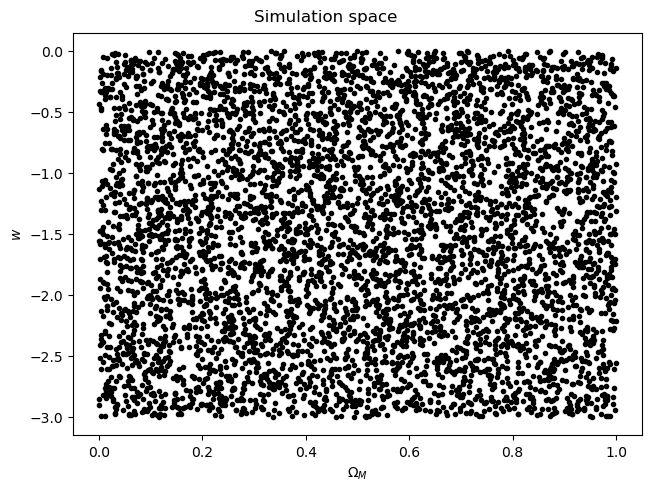

In [14]:
with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)
N = 5500  # select number of TRAINING sims
N_val = 700
N_lc = 73  # lc per sim (maximum possible over all sims)
#get minimum lenght to have maxitems per omega/lambda couple.
# lc_per_sim = []
# for i in range(N):
#     nlc = sims[i].get('zhd').shape[0]  # should be 73
#     lc_per_sim.append(nlc)
# N_lc = np.min(lc_per_sim)
# print('miminum simulation per omega,w:', N_lc)


# omega_list = np.empty(N)
# w = np.empty(N)
# training
theta = np.empty((N, 2))
mu = np.empty((N, N_lc))
zhd = np.empty((N, N_lc))
for i in range(N):
    # omega_list[i] = train[i].get('omega')
    # w[i] = train[i].get('w')
    theta[i] = (sims[i].get('omega'), sims[i].get('w'))
    mu[i] = sims[i].get('mu')[:N_lc]
    zhd[i] = sims[i].get('zhd')[:N_lc]

# validation
theta_val = np.empty((N_val, 2))
mu_val = np.empty((N_val, N_lc))
zhd_val = np.empty((N_val, N_lc))
for i, j in enumerate(range(N, N + N_val)):
    # omega_list[i] = train[i].get('omega')
    # w[i] = train[i].get('w')
    theta_val[i] = (sims[j].get('omega'), sims[j].get('w'))
    mu_val[i] = sims[j].get('mu')[:N_lc]
    zhd_val[i] = sims[j].get('zhd')[:N_lc]

fig, ax = plt.subplots(layout='constrained')
fig.suptitle("Simulation space")

ax.plot(theta[:, 0], theta[:, 1], '.k')
ax.set_xlabel(r"$\Omega_M$")
ax.set_ylabel(r"$w$")
plt.show()

In [5]:
2404.12484v4.pdf# standardise
theta_mean, theta_std = theta.mean(axis=0), theta.std(axis=0)
mu_mean, mu_std = mu.mean(axis=0), mu.std(axis=0)
zhd_mean, zhd_std = zhd.mean(axis=0), zhd.std(axis=0)

mu = torch.tensor((mu - mu_mean) / mu_std).float()
zhd = torch.tensor((zhd - zhd_mean) / zhd_std).float()
theta = torch.tensor((theta - theta_mean) / theta_std).float()
x = torch.cat([mu,zhd], dim=1)

mu_val = torch.tensor((mu_val - mu_mean) / mu_std).float()
zhd_val = torch.tensor((zhd_val - zhd_mean) / zhd_std).float()
theta_val = torch.tensor((theta_val - theta_mean) / theta_std).float()
x_val = torch.cat([mu_val,zhd_val], dim=1)
# save means and stds, we need them to standardise the test... I think...
# np.savez("/home/ubuntu/SNANA/nre/gioTesting/meansNstds.npz", theta_mean=theta_mean, theta_std=theta_std, mu_mean=mu_mean, mu_std=mu_std, zhd_mean=zhd_mean, zhd_std=zhd_std)




# Evaluate loss; initially it should be around -log(0.5) = 0.693
nre = NeuralRatioEstimator(x_dim=N_lc*2, theta_dim=2, hidden_dim=512, layers=10)
with torch.no_grad():  # Boh, non so se serva con torch lightning, non so come funzioni torch_lightning
    nre.eval()
    print(nre.loss(x, theta))

batch_size = 100

dataset_train, dataset_val = TensorDataset(x, theta), TensorDataset(x_val, theta_val)


train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=False)
logger = pl.loggers.CSVLogger('test', name="test")
trainer = pl.Trainer(max_epochs=50, logger=logger)
nre.train()
trainer.fit(model=nre, train_dataloaders=train_loader, val_dataloaders=val_loader)

/tmp/ipykernel_796193/1663672098.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads

tensor([0.6825, 0.7039, 0.6825,  ..., 0.7039, 0.6825, 0.7039])


Sanity Checking: |                                                               | 0/? [00:00<?, ?it/s]

/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |                                                                      | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


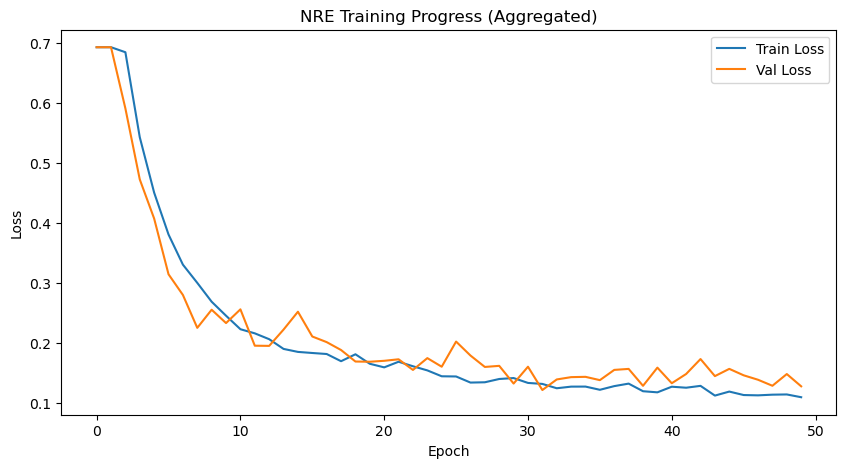

In [79]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

# Aggregate by epoch to remove NaNs
# This takes the non-NaN value for each epoch
epoch_metrics = metrics.groupby('epoch').max()

plt.figure(figsize=(10, 5))


# Plot from the aggregated dataframe
if 'train_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss')

if 'val_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('NRE Training Progress (Aggregated)')
plt.show()

# Load stuff - test on real data

In [3]:
npLoad = np.load("/home/ubuntu/SNANA/nre/gioTesting/meansNstds.npz")
theta_mean = npLoad["theta_mean"]
theta_std = npLoad["theta_std"]
mu_mean = npLoad["mu_mean"]
mu_std = npLoad["mu_std"]
zhd_mean = npLoad["zhd_mean"]
zhd_std = npLoad["zhd_std"]

for key in npLoad.keys(): print(key)

npLoad.close()

theta_mean
theta_std
mu_mean
mu_std
zhd_mean
zhd_std


In [4]:
nre = NeuralRatioEstimator.load_from_checkpoint('test/test/version_5/checkpoints/epoch=49-step=2750.ckpt', x_dim=73*2, theta_dim=2, hidden_dim=512, layers=10)
nre.eval()


NeuralRatioEstimator(
  (classifier): Sequential(
    (0): Linear(in_features=148, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): GELU(approximate='none')
    (4): Dropout(p=0.45, inplace=False)
    (5): Linear(in_features=512, out_features=512, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.45, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): GELU(approximate='none')
    (10): Dropout(p=0.45, inplace=False)
    (11): Linear(in_features=512, out_features=512, bias=True)
    (12): GELU(approximate='none')
    (13): Dropout(p=0.45, inplace=False)
    (14): Linear(in_features=512, out_features=512, bias=True)
    (15): GELU(approximate='none')
    (16): Dropout(p=0.45, inplace=False)
    (17): Linear(in_features=512, out_features=512, bias=True)
    (18): GELU(approximate='none')
    (19): Dropout(p=0.45, inplace=False)
    (20): Linear(in_features

100%|█████████████████████████████████████████████████████████████████████| 5000/5000 [01:44<00:00, 47.94it/s]


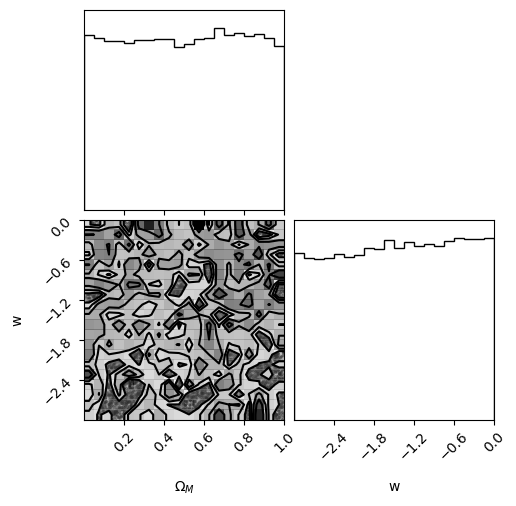

In [6]:
sampler = giot.test_test_data(theta_mean, theta_std, mu_mean, mu_std, zhd_mean, zhd_std, nre)
# plt.savefig("corner.png")
# plt.show()

# gg Code

In [ ]:

def log_like(theta, x):
    """ Log-likelihood ratio estimator using trained classifier logits. """
    x = torch.Tensor(x)
    theta = torch.Tensor(theta)

    x = (x - torch.mean(x)) / torch.std(x)
    theta = (theta - torch.mean(theta)) / torch.std(theta)

    x = torch.atleast_1d(x)
    theta = torch.atleast_1d(theta)

    with torch.no_grad():
        return nre.classifier(torch.cat([x, theta], dim=-1)).squeeze().item()



theta_test = np.array([0.34, -1])

mu_test, zhd_test = f.sim_wrapper(theta_test, nome_run_nre)

mu_test = mu_test[:X]
mu_test = (mu_test - mu_test.mean()) / mu_test.std()

zhd_test = zhd_test[:X]
zhd_test = (zhd_test - zhd_test.mean()) / zhd_test.std()

x_test = np.concatenate((mu_test, zhd_test))

log_like(theta_test, x_test)

def log_post(theta, x):
    """ Log-posterior distribution, for sampling.
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    else:
        return lp + log_like(theta, x)

def log_prior(theta):
    if (0 <= theta[0] <= 1) and (-3 <= theta[1] <= 0):
        return 0.0
    return -np.inf

initial_guess = [0.5, -1.5]
# Set up the minimizer_kwargs for the basinhopping algorithm
minimizer_kwargs = {"method": "L-BFGS-B", "bounds": ((0, 1), (-3, 0))}

# Perform the optimization using basinhopping
opt = basinhopping(
    lambda thetas: -float(log_like(thetas, x_test)), 
    initial_guess, 
    minimizer_kwargs=minimizer_kwargs
)
print(f"MLE parameters: {opt.x}; true parameters: {theta_test}")
ndim, nwalkers = 2, 32

# Fix args: log_post only takes (theta, x), so pass only x_test
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_post, args=(x_test,))

# Start walkers near the MLE solution
pos = opt.x + 1e-3 * np.random.randn(nwalkers, ndim)
sampler.run_mcmc(pos, 5000, progress=True)

flat_samples = sampler.get_chain(discard=1000, flat=True)

# 4. Corner plot
# Truths should be your actual test parameters, not the arbitrary [50, 0.8]
import corner
corner.corner(
    flat_samples, 
    labels=["param_1", "param_2"], 
    truths=theta_test, 
    smooth=1.
);